# Results Analysis: Molecular Docking Prediction with DiffDock

This notebook documents the exploratory analysis and structural evaluation of the results generated by the DiffDock pipeline.

**Objectives:**
1. Extract and clean the *confidence scores* of the predicted ligands, with quality control (QA) of failed runs.
2. Quantitatively analyze the distribution of the predictions.
3. Visualize the 3D complex (protein-ligand) with the highest binding probability, including the binding pocket.
4. Validate the top pose quantitatively against the crystallographic reference, where available.

## About the validation case: streptavidin (1STP) + biotin

Streptavidin-biotin was chosen for local validation because it has one of the best-characterized, deepest, and most unambiguous binding pockets known — ideal for sanity-checking a pipeline both visually and quantitatively.

**Caveat worth stating explicitly:** PDB entry 1STP was deposited in 1992. DiffDock's train/test split uses a temporal cutoff — complexes from 2018 or earlier are used for training, and only structures from 2019 onward are held out as the test set. A complex this old and this well-studied is very likely part of DiffDock's training data (or has close homologs in it). This result is therefore a good end-to-end pipeline sanity check, **not** a generalization benchmark — the model may already be familiar with this exact pocket.

## What the DiffDock confidence score is (and isn't)

The confidence score comes from a *separate* model trained alongside the diffusion (pose-generating) model. Its training target is a classification signal: whether a generated pose is likely to have heavy-atom RMSD < 2&Aring; from the true crystallographic pose. In practice, values above 0 are associated with high-confidence poses, roughly -1.5 to 0 with moderate confidence, and below -1.5 with low confidence.

Two things it is **not**:
- It is **not** a physical energy term — it does not directly encode thermodynamics, steric clashes, or hydrogen-bonding geometry, even though poses with those problems tend to score lower in practice.
- It is **not** binding affinity. DiffDock predicts pose (3D structure) and confidence (structural plausibility), not &Delta;G, K<sub>d</sub>, or K<sub>i</sub>. A high confidence score means "this looks like a correctly docked structure," not "this ligand binds tightly."

In [1]:
# Import necessary libraries
import os
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

# Aesthetic configuration for plots
sns.set_theme(style="whitegrid", palette="mako")

## Results loading and quality control (QA)

We iterate over **all** subfolders in `results/` (one per protein-ligand complex), not a fixed path. A complex that did not produce any poses (docking failure) is detected and reported, rather than silently disappearing from the analysis.

The protein path for each complex is taken from the manifest generated by `run_pipeline.py` (`data/inference_map.csv`) — the same single source of truth used by the orchestrator to launch DiffDock — instead of reconstructing paths from the results folder name.

In [2]:
# --- Configuration ---
results_root = Path("results")
manifest_path = Path("data/inference_map.csv")  # generated by run_pipeline.py / config.sh

# Confirmed against gcorso/DiffDock source code (inference.py):
# writes f'rank{rank+1}_confidence{confidence[rank]:.2f}.sdf' for each pose.
pattern = re.compile(r"rank(\d+)_confidence([-\.\d]+)\.sdf$")

# Map complex_name -> protein_path, taken from the orchestrator manifest
protein_by_complex = {}
if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
    protein_by_complex = dict(zip(manifest["complex_name"], manifest["protein_path"]))
else:
    print(f"[WARNING] {manifest_path} not found; 3D visualization will require a manual path.")

if not results_root.exists():
    raise FileNotFoundError(
        f"'{results_root}' does not exist. Verify that the pipeline was executed "
        f"and that this notebook is in the project root."
    )

complex_dirs = sorted([d for d in results_root.iterdir() if d.is_dir()])
if not complex_dirs:
    raise FileNotFoundError(f"'{results_root}' exists but contains no result subfolders.")

data = []
qa_failed_complexes = []

for complex_dir in complex_dirs:
    matched_any = False
    for filename in os.listdir(complex_dir):
        match = pattern.search(filename)
        if match:
            matched_any = True
            data.append({
                "Complex": complex_dir.name,
                "Rank": int(match.group(1)),
                "Confidence": float(match.group(2)),
                "Filepath": str(complex_dir / filename),
            })
    if not matched_any:
        qa_failed_complexes.append(complex_dir.name)

df_results = pd.DataFrame(data)

if df_results.empty:
    ejemplo = os.listdir(complex_dirs[0])[:10]
    raise ValueError(
        "No file matching the pattern 'rankN_confidenceX.sdf' found in any "
        f"subfolder of '{results_root}'. Actual content of '{complex_dirs[0].name}' "
        f"for debugging: {ejemplo}"
    )

df_results = df_results.sort_values(by=["Complex", "Rank"]).reset_index(drop=True)

print(f"Complexes with at least one pose: {df_results['Complex'].nunique()}")
print(f"Total poses extracted: {len(df_results)}")
if qa_failed_complexes:
    print(f"[QA] Complexes WITHOUT detected poses (possible docking failure): {qa_failed_complexes}")
else:
    print("[QA] All complexes produced at least one pose. No failures detected.")

display(df_results.head(10))

Complexes with at least one pose: 1
Total poses extracted: 20
[QA] All complexes produced at least one pose. No failures detected.


,Complex,Rank,Confidence,Filepath
0,1STP_clean_BTN_ideal,1,0.41,results/1STP_clean_BTN_ideal/rank1_confidence0...
1,1STP_clean_BTN_ideal,1,0.35,results/1STP_clean_BTN_ideal/rank1_confidence0...
2,1STP_clean_BTN_ideal,2,0.33,results/1STP_clean_BTN_ideal/rank2_confidence0...
3,1STP_clean_BTN_ideal,2,0.34,results/1STP_clean_BTN_ideal/rank2_confidence0...
4,1STP_clean_BTN_ideal,3,0.33,results/1STP_clean_BTN_ideal/rank3_confidence0...
5,1STP_clean_BTN_ideal,3,0.32,results/1STP_clean_BTN_ideal/rank3_confidence0...
6,1STP_clean_BTN_ideal,4,0.27,results/1STP_clean_BTN_ideal/rank4_confidence0...
7,1STP_clean_BTN_ideal,4,0.32,results/1STP_clean_BTN_ideal/rank4_confidence0...
8,1STP_clean_BTN_ideal,5,0.27,results/1STP_clean_BTN_ideal/rank5_confidence0...
9,1STP_clean_BTN_ideal,5,0.32,results/1STP_clean_BTN_ideal/rank5_confidence0...


### Summary per complex

Control table: best score (Rank 1), number of generated poses, and QA status per complex. Complexes without poses also appear here (they do not disappear from the analysis), marked as failed.

In [3]:
all_complex_names = [d.name for d in complex_dirs]
summary = pd.DataFrame({"Complex": all_complex_names})

pose_counts = df_results.groupby("Complex").size().rename("Generated_poses")
best_score = (
    df_results[df_results["Rank"] == 1]
    .set_index("Complex")["Confidence"]
    .rename("Confidence_Rank1")
)

summary = summary.merge(pose_counts, on="Complex", how="left").merge(best_score, on="Complex", how="left")
summary["Generated_poses"] = summary["Generated_poses"].fillna(0).astype(int)
summary["QA_Status"] = summary["Generated_poses"].apply(lambda n: "OK" if n > 0 else "FAILURE: no poses generated")

display(summary.sort_values("Confidence_Rank1", ascending=False))

,Complex,Generated_poses,Confidence_Rank1,QA_Status
0,1STP_clean_BTN_ideal,20,0.41,OK
1,1STP_clean_BTN_ideal,20,0.35,OK


## Quantitative visualization

One panel per complex (currently only one; with more complexes, additional panels are added automatically without changing the code).

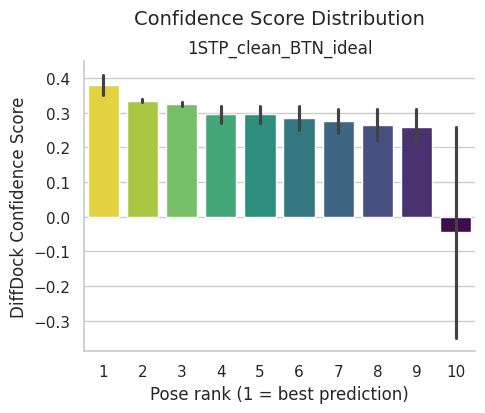

In [4]:
g = sns.catplot(
    data=df_results,
    x="Rank", y="Confidence",
    col="Complex", col_wrap=3,
    kind="bar", hue="Rank", palette="viridis_r", legend=False,
    height=4, aspect=1.1,
)
g.set_titles("{col_name}")
g.set_axis_labels("Pose rank (1 = best prediction)", "DiffDock Confidence Score")

ax = g.axes.flat[0]
bbox = ax.get_position()
center_x = (bbox.x0 + bbox.x1) / 2
g.figure.suptitle("Confidence Score Distribution", x=center_x, y=1.03, ha='center', fontsize=14)

plt.show()

## 3D visual inspection

The complex with the best Rank 1 is automatically selected (with a single complex, it's simply that one). The protein path is taken from the orchestrator's manifest; if it doesn't exist or the path is no longer valid on this machine (the CSV saves absolute paths resolved where it was generated), a warning is given and a manual fallback path is used.

Unlike showing just the isolated ligand, here the full protein **residues** within 5&Aring; of the ligand are highlighted (not just individual nearby atoms — see the `byres` note in the code), allowing us to judge whether it actually fits into a binding cavity rather than just floating near the surface.

In [5]:
best_complex = (
    summary[summary["Generated_poses"] > 0]
    .sort_values("Confidence_Rank1", ascending=False)
    .iloc[0]["Complex"]
)

best_row = df_results[(df_results["Complex"] == best_complex) & (df_results["Rank"] == 1)].iloc[0]
best_ligand_path = best_row["Filepath"]

protein_path = protein_by_complex.get(best_complex)
if protein_path is None or not Path(protein_path).exists():
    if protein_path is not None:
        print(f"[WARNING] Manifest path does not exist on this machine: {protein_path}")
    protein_path = "data/toy_dataset/proteins/1STP_clean.pdb"  # ADJUST if necessary
    print(f"[WARNING] Using manual protein path for '{best_complex}': {protein_path}")


def show_complex(protein_file, ligand_file):
    with open(protein_file, "r") as f:
        protein_data = f.read()
    with open(ligand_file, "r") as f:
        ligand_data = f.read()

    view = py3Dmol.view(width=800, height=500)

    # Full protein as context (translucent cartoon)
    view.addModel(protein_data, "pdb")
    view.setStyle({"model": 0}, {"cartoon": {"color": "white", "opacity": 0.85}})

    # Ligand (best pose)
    view.addModel(ligand_data, "sdf")
    view.setStyle({"model": 1}, {"stick": {"colorscheme": "magentaCarbon", "radius": 0.2}})

    # Binding pocket: FULL residues (byres=True) with any atom within 5A of the
    # ligand, not just the individual nearby atoms -- avoids rendering
    # disconnected atom fragments and shows complete side chains, which is the
    # standard convention for pocket figures in structural biology.
    view.addStyle(
        {"model": 0, "byres": True, "within": {"distance": 5, "sel": {"model": 1}}},
        {"stick": {"colorscheme": "cyanCarbon", "radius": 0.15}},
    )

    view.zoomTo({"model": 1})
    return view


print(f"Visualizing: {best_complex} (Rank 1, confidence={best_row['Confidence']:.2f})")
view = show_complex(protein_path, best_ligand_path)
view.show()

Visualizing: 1STP_clean_BTN_ideal (Rank 1, confidence=0.41)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Quantitative validation: RMSD against the crystallographic pose

**Important:** the ground-truth ligand pose is *not* in `protein_path`, that file is the `_clean.pdb` receptor DiffDock actually docked against, and it has had all HETATM records (including the true biotin) stripped on purpose. That's correct practice for a real blind-docking input (you don't want to hand the model the answer), but it means the true pose has to be fetched separately from the original, unmodified PDB deposition.

We download the original entry from RCSB, extract the co-crystallized ligand, restore its bond orders from a biotin SMILES template (raw PDB coordinates carry no bond-order information), and compute the symmetry-corrected heavy-atom RMSD against the predicted Rank-1 pose with `spyrmsd`, the same tool and methodology the original DiffDock paper uses to report its RMSD < 2&Aring; success rate.

1STP is a streptavidin tetramer, the original file contains multiple bound biotin copies (one per chain), all sharing the same residue name. We pick whichever copy is geometrically closest to the predicted pose, since any of the (biologically equivalent) copies is a valid reference and the nearest one gives the fairest comparison.

Requires internet access to `files.rcsb.org` at run time. Set `REFERENCE_PDB_ID = None` to skip this check entirely (e.g. for a complex with no deposited crystal structure to compare against). Wrapped in a try/except so it never breaks the rest of the notebook.

In [6]:
import urllib.request
import numpy as np

REFERENCE_PDB_ID = "1STP"  # Set to None to skip this check for complexes with no known crystal structure

STANDARD_AA = {
    "ALA", "ARG", "ASN", "ASP", "CYS", "GLN", "GLU", "GLY", "HIS", "ILE",
    "LEU", "LYS", "MET", "PHE", "PRO", "SER", "THR", "TRP", "TYR", "VAL", "HOH",
}
LIGAND_RESIDUE_NAME = "BTN"  # PDB chemical component code for biotin (3-char HETATM code, NOT the input filename)
BIOTIN_SMILES = "O=C(O)CCCC[C@@H]1SC[C@@H]2NC(=O)N[C@H]12"

try:
    if REFERENCE_PDB_ID is None:
        raise ValueError("No REFERENCE_PDB_ID set for this complex; skipping RMSD check.")

    from spyrmsd import io
    from spyrmsd.rmsd import rmsdwrapper

    # Fetch the ORIGINAL deposition (not protein_path -- see markdown above).
    reference_pdb_path = f"/tmp/{REFERENCE_PDB_ID}_original.pdb"
    urllib.request.urlretrieve(f"https://files.rcsb.org/download/{REFERENCE_PDB_ID}.pdb", reference_pdb_path)

    reference_mol = Chem.MolFromPDBFile(reference_pdb_path, removeHs=True, sanitize=False)
    fragments = Chem.SplitMolByPDBResidues(reference_mol)
    true_ligand_merged = fragments.get(LIGAND_RESIDUE_NAME)

    if true_ligand_merged is None or true_ligand_merged.GetNumAtoms() == 0:
        hetero = [k for k in fragments if k not in STANDARD_AA]
        raise ValueError(
            f"Residue '{LIGAND_RESIDUE_NAME}' not found in downloaded {REFERENCE_PDB_ID}.pdb. "
            f"Other non-standard residues present: {hetero}"
        )

    # SplitMolByPDBResidues groups ALL copies sharing a residue name into one
    # Mol (confirmed: 1STP is a tetramer, so there are multiple bound BTN
    # copies here). Split them apart and keep the one nearest to the predicted
    # pose -- any biologically equivalent copy is a valid reference, and the
    # nearest one is the fairest comparison.
    predicted_mol = next(Chem.SDMolSupplier(best_ligand_path))
    predicted_centroid = np.mean(predicted_mol.GetConformer().GetPositions(), axis=0)

    copies = Chem.GetMolFrags(true_ligand_merged, asMols=True)
    centroids = [np.mean(c.GetConformer().GetPositions(), axis=0) for c in copies]
    closest_idx = int(np.argmin([np.linalg.norm(c - predicted_centroid) for c in centroids]))
    true_ligand_raw = copies[closest_idx]

    # Raw PDB coordinates carry no reliable bond orders -- restore them from a
    # known reference template (verified against biotin's molecular formula
    # C10H16N2O3S before using it here).
    template = Chem.MolFromSmiles(BIOTIN_SMILES)
    true_ligand = AllChem.AssignBondOrdersFromTemplate(template, true_ligand_raw)

    true_sdf_path = "/tmp/true_ligand_from_crystal.sdf"
    writer = Chem.SDWriter(true_sdf_path)
    writer.write(true_ligand)
    writer.close()

    ref = io.loadmol(true_sdf_path)
    pred = io.loadmol(best_ligand_path)

    rmsd_value = rmsdwrapper(ref, pred, center=False, minimize=False)[0]
    verdict = "SUCCESS (RMSD < 2A, DiffDock paper's own criterion)" if rmsd_value < 2.0 else "INCORRECT POSE (RMSD >= 2A)"
    print(f"Rank-1 RMSD vs. crystallographic pose (closest of {len(copies)} copies): {rmsd_value:.2f} A -> {verdict}")

except Exception as e:
    print(f"[WARNING] Could not compute RMSD against the crystallographic reference: {e}")
    print("This does not affect the rest of the analysis -- it's an optional quantitative check.")

Rank-1 RMSD vs. crystallographic pose (closest of 1 copies): 0.59 A -> SUCCESS (RMSD < 2A, DiffDock paper's own criterion)


[17:49:52] WARNING: More than one matching pattern found - picking one



### Visual Inspection (Rank 1)

The interactive visualization confirms the model's main prediction. The ligand (magenta) is located next to the full binding pocket residues highlighted in cyan, which allows judging directly whether the docking occurs in a logical protein cavity and not on the solvent-exposed surface.

Since this is a quick local CPU validation (reduced `--steps`/`--samples` parameters), a positive confidence score together with an RMSD below 2&Aring; against the crystallographic pose (computed above) is stronger evidence than the confidence score alone that the preprocessing, inference, and saving pipeline works correctly end-to-end. As noted earlier, this specific complex is likely familiar to the model from training, so this is a pipeline validation, not a generalization benchmark, the next step is running this same pipeline on complexes the model has not seen, ideally on a production HPC environment for higher-precision sampling.